# Chapter 2: Transversality and Intersection

**Source Span.** `Differential Topology.pdf` printed pages `57-93`, covering manifolds with boundary, the special structure of compact one-manifolds, transversality for maps into submanifolds, intersection theory modulo two, winding numbers, the Jordan-Brouwer separation theorem, and the Borsuk-Ulam theorem.

**Chapter Goal.** Convert transversality into a counting machine. A boundary makes one-dimensional manifolds behave like intervals and circles; transversality makes intersections finite and stable; modulo two counts survive deformation without needing orientation; winding numbers turn intersection parity into a separation test; and Borsuk-Ulam appears as a forced antipodal coincidence.

This notebook is built around the chapter's most useful habit: replace a hard global statement with a transverse local model, count the finite set that appears, and then check which count survives a homotopy. The visuals are therefore not decorative. The collar diagram shows why boundary points have half-space coordinates. The one-manifold panel shows why compact one-manifolds split into interval and circle pieces. The parity lab shows that intersection points can be born or die in pairs. The winding lab turns a closed curve into an integer-valued diagnostic for regions in the complement. The Borsuk-Ulam cell uses a concrete function on the circle and searches for antipodal equality.

The source is used only for chapter structure and mathematical vocabulary. All prose, code, and diagrams here are original teaching material designed to let the notebook stand alone.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
import sympy as sp

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate the Differential Topology course root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib, save_plotly_html

UNIT_KEY = "chapter-02-transversality-and-intersection"
UNIT_TITLE = "Transversality and Intersection"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"
TRACKED_ARTIFACTS = []
np.set_printoptions(precision=4, suppress=True)
print(f"Book root: {BOOK_ROOT}")


Book root: D:\Geometry\Differential-Topology


## Visual Storyboard

1. **Boundary collar and one-manifold census.** A half-space chart is shown next to interval and circle components. The learner should inspect how endpoints are boundary points and how compactness leaves no loose ends except paired interval endpoints.
2. **Transversality perturbation.** A target circle is intersected by a family of lines. Tangent contact is nontransverse; a small perturbation creates either two crossings or none. The saved table records ordinary counts and mod two counts.
3. **Winding and separation lab.** A closed curve carries a winding-number function on selected test points. Points in the same component of the complement have the same winding number, while crossing the curve changes the value.
4. **Borsuk-Ulam circle experiment.** For a smooth scalar function on `S^1`, the notebook plots `f(theta)-f(theta+pi)` and locates antipodal pairs with equal values.

## Library Routing

| Concept | Representation | Library | Why this route is used | Validation target |
| --- | --- | --- | --- | --- |
| Boundary and one-manifolds | Half-space collar plus component graph | Matplotlib + NetworkX | Boundary behavior is visual and combinatorial | endpoint count is even for compact interval pieces |
| Transversality mod two | Line-circle intersections through a parameter | NumPy + Matplotlib | Finite intersections and pair creation are easy to inspect | parity is stable away from tangency |
| Winding/Jordan-Brouwer | Closed curve and test points | Plotly + NumPy | Interactive inspection clarifies components of the complement | winding values are integer after angle unwrapping |
| Borsuk-Ulam | Antipodal residual on a circle | Matplotlib + JSON | A concrete residual exposes forced zeros | sign changes produce antipodal equality candidates |


## Boundary Coordinates And Compact One-Manifolds

A manifold with boundary is locally modeled on a half-space rather than all of Euclidean space. That small change has large consequences. Interior points have neighborhoods that extend in every coordinate direction. Boundary points have one missing side, and collars organize the nearby geometry by a boundary coordinate and an inward normal coordinate. The first panel below shows the half-disk version of that local picture. The arrows are not a proof, but they indicate why boundary orientation and boundary transversality later depend on separating tangent directions from the outward normal direction.

The second panel compresses the classification behavior used repeatedly in the chapter: a compact one-manifold is assembled from circles and closed intervals. In mod two arguments, intervals contribute two boundary endpoints, while circles contribute none. This is the engine behind many parity statements. If a one-dimensional preimage is compact and its boundary is a finite set, that finite set has even cardinality. The chapter turns that elementary observation into intersection invariants, nonretraction consequences, and eventually winding-number statements.


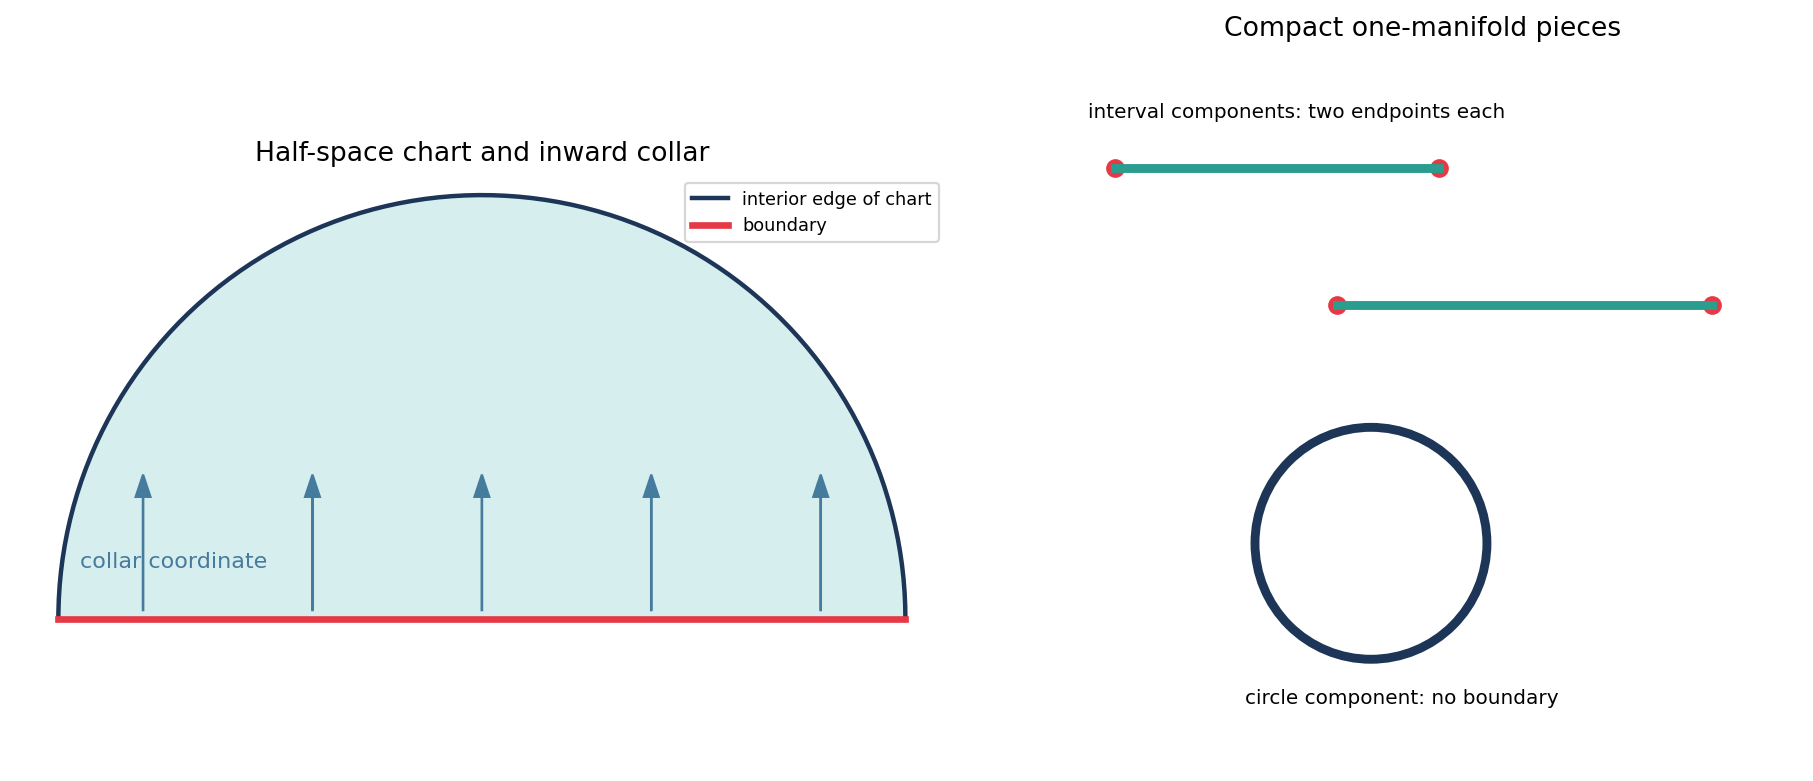

[{'component': 'closed interval A',
  'boundary_points': 2,
  'mod2_boundary_count': 0},
 {'component': 'closed interval B',
  'boundary_points': 2,
  'mod2_boundary_count': 0},
 {'component': 'circle C', 'boundary_points': 0, 'mod2_boundary_count': 0}]

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Boundary half-disk/collar diagram.
th = np.linspace(0, np.pi, 200)
axes[0].fill_between(np.cos(th), 0, np.sin(th), color="#a8dadc", alpha=0.45)
axes[0].plot(np.cos(th), np.sin(th), color="#1d3557", lw=2, label="interior edge of chart")
axes[0].plot([-1, 1], [0, 0], color="#e63946", lw=3, label="boundary")
for x0 in np.linspace(-0.8, 0.8, 5):
    axes[0].arrow(x0, 0.02, 0, 0.32, head_width=0.035, color="#457b9d", length_includes_head=True)
axes[0].text(-0.95, 0.12, "collar coordinate", color="#457b9d")
axes[0].set_title("Half-space chart and inward collar")
axes[0].set_aspect("equal", adjustable="box")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].axis("off")

# One-manifold component census: two intervals and one circle.
for y0, xstart, xend in [(0.75, -0.9, 0.05), (0.35, -0.25, 0.85)]:
    axes[1].plot([xstart, xend], [y0, y0], color="#2a9d8f", lw=4)
    axes[1].scatter([xstart, xend], [y0, y0], color="#e63946", s=55)
circle = plt.Circle((-0.15, -0.35), 0.34, fill=False, color="#1d3557", lw=4)
axes[1].add_patch(circle)
axes[1].text(-0.98, 0.90, "interval components: two endpoints each", fontsize=9)
axes[1].text(-0.52, -0.82, "circle component: no boundary", fontsize=9)
axes[1].set_xlim(-1.1, 1.1)
axes[1].set_ylim(-1.0, 1.1)
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_title("Compact one-manifold pieces")
axes[1].axis("off")
fig.tight_layout()
boundary_path = save_matplotlib(fig, FIGURES / "boundary-collar-one-manifold-census.png")
plt.close(fig)
TRACKED_ARTIFACTS.append(boundary_path)

component_rows = [
    {"component": "closed interval A", "boundary_points": 2, "mod2_boundary_count": 0},
    {"component": "closed interval B", "boundary_points": 2, "mod2_boundary_count": 0},
    {"component": "circle C", "boundary_points": 0, "mod2_boundary_count": 0},
]
component_csv = save_csv(component_rows, TABLES / "compact-one-manifold-boundary-census.csv")
component_json = save_json({"rows": component_rows, "total_boundary_points": 4, "total_mod2": 0}, CHECKS / "compact-one-manifold-boundary-census.json")
TRACKED_ARTIFACTS.extend([component_csv, component_json])
display_artifact(boundary_path, width=820)
component_rows


## Transversality And Mod Two Intersection

Intersection theory modulo two discards signs and keeps the parity of a transverse finite intersection. That sounds crude, but it is robust. In a one-parameter deformation, two intersection points can appear or disappear together at a tangency. Because they appear in pairs, the count modulo two survives as long as the boundary conditions required by the chapter are respected. The next figure shows exactly that local event using horizontal lines against a circle. At the tangent height the line is not transverse. Above it there are no crossings; below it there are two; the parity is the same on both transverse sides.

This is the conceptual bridge from transversality to topological consequences. A map is adjusted until it meets the target submanifold transversely. The finite intersection set is counted modulo two. A homotopy sweeps out a compact one-manifold whose boundary is the difference between the two intersection sets, and the one-manifold boundary census explains why the parity cannot change. The saved table keeps the numerical count attached to the picture.


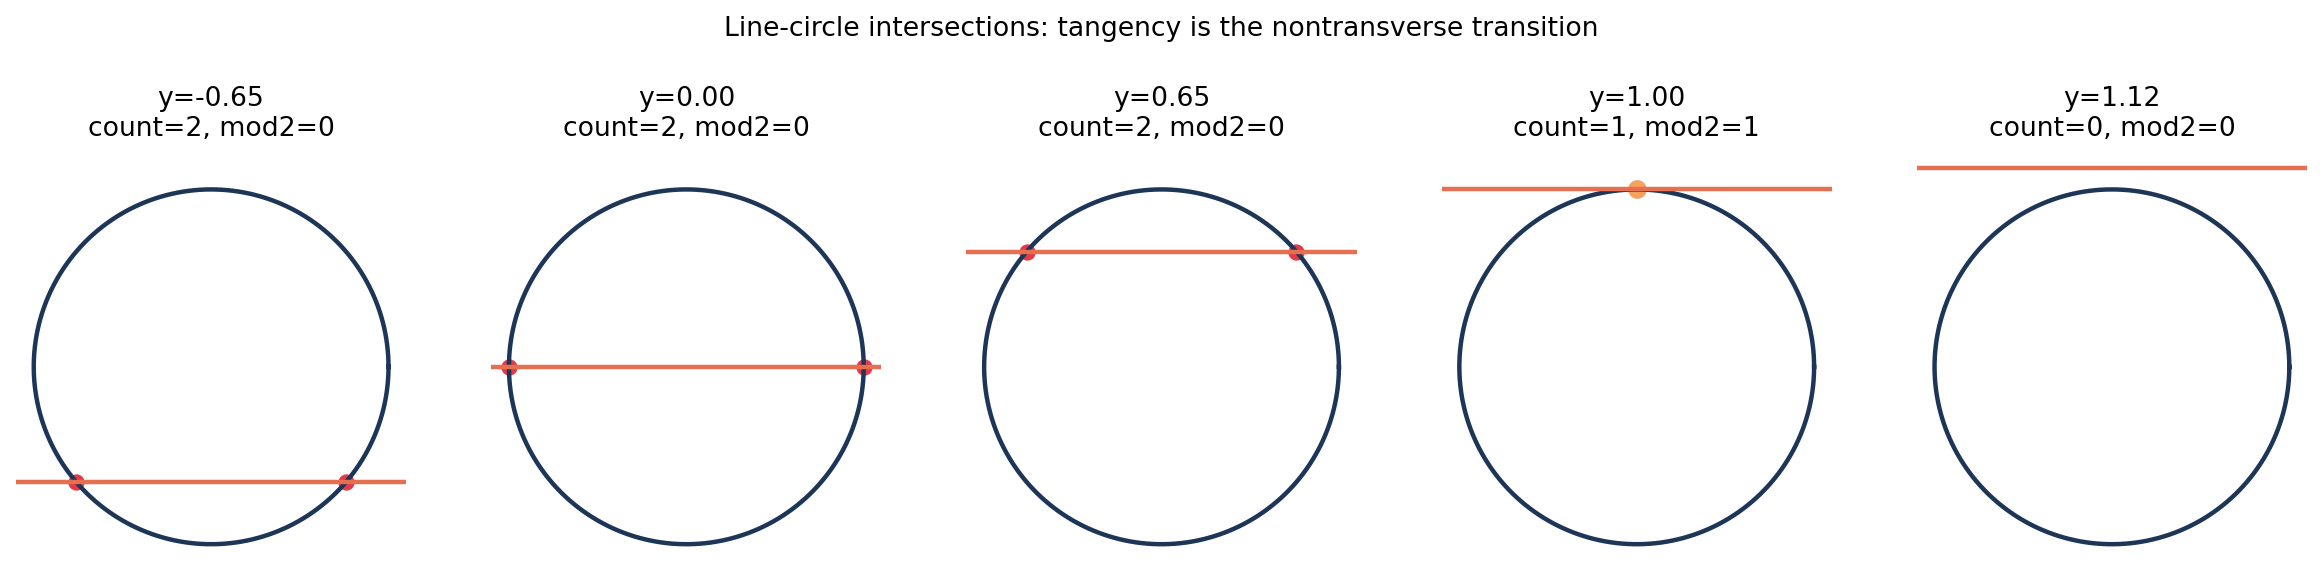

[{'line_height': -0.65,
  'ordinary_count': 2,
  'mod2_count': 0,
  'transverse': True},
 {'line_height': 0.0,
  'ordinary_count': 2,
  'mod2_count': 0,
  'transverse': True},
 {'line_height': 0.65,
  'ordinary_count': 2,
  'mod2_count': 0,
  'transverse': True},
 {'line_height': 1.0,
  'ordinary_count': 1,
  'mod2_count': 1,
  'transverse': False},
 {'line_height': 1.12,
  'ordinary_count': 0,
  'mod2_count': 0,
  'transverse': True}]

In [3]:
y_levels = [-0.65, 0.0, 0.65, 1.0, 1.12]
intersection_rows = []
fig, axes = plt.subplots(1, len(y_levels), figsize=(15, 3.4), sharex=True, sharey=True)
theta = np.linspace(0, 2*np.pi, 400)
for ax, c in zip(axes, y_levels):
    ax.plot(np.cos(theta), np.sin(theta), color="#1d3557", lw=2)
    ax.axhline(c, color="#e76f51", lw=2)
    disc = 1 - c**2
    if disc > 1e-10:
        xs = [-math.sqrt(disc), math.sqrt(disc)]
        ys = [c, c]
        count = 2
        transverse = True
        ax.scatter(xs, ys, color="#e63946", s=40)
    elif abs(disc) <= 1e-10:
        xs = [0.0]
        ys = [c]
        count = 1
        transverse = False
        ax.scatter(xs, ys, color="#f4a261", s=55)
    else:
        count = 0
        transverse = True
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"y={c:.2f}\ncount={count}, mod2={count%2}")
    ax.axis("off")
    intersection_rows.append({"line_height": c, "ordinary_count": count, "mod2_count": count % 2, "transverse": transverse})
fig.suptitle("Line-circle intersections: tangency is the nontransverse transition", y=1.05)
fig.tight_layout()
parity_path = save_matplotlib(fig, FIGURES / "mod2-intersection-parity-through-tangency.png")
plt.close(fig)
parity_csv = save_csv(intersection_rows, TABLES / "mod2-intersection-parity-through-tangency.csv")
parity_json = save_json({"rows": intersection_rows, "transverse_parities": [r["mod2_count"] for r in intersection_rows if r["transverse"]]}, CHECKS / "mod2-intersection-parity-through-tangency.json")
TRACKED_ARTIFACTS.extend([parity_path, parity_csv, parity_json])
display_artifact(parity_path, width=900)
intersection_rows


## Winding, Separation, And Antipodal Coincidence

Winding number is the chapter's way of turning a closed curve into a test for points in the complement. Around a point not on the curve, unwrap the angle from that point to the moving curve. The total change in angle divided by `2*pi` is an integer. Points that can be connected without crossing the curve have the same integer; crossing the curve changes it. This is the computational shadow of the separation statements in the chapter, including the Jordan-Brouwer theme that embedded codimension-one submanifolds divide ambient space.

Borsuk-Ulam uses a different but related parity pressure. For a continuous function on the circle with values in the line, consider the antipodal residual `f(theta)-f(theta+pi)`. The residual changes sign under `theta -> theta+pi`, so zeros are forced. A zero means an antipodal pair has equal values. The notebook below makes this visible for a smooth trigonometric function and records candidate pairs. The example is low-dimensional, but the habit matches the theorem: symmetry plus topology forces coincidence.


In [4]:
def gamma(th):
    return np.column_stack([
        np.cos(th) + 0.22*np.cos(2*th),
        np.sin(th) - 0.16*np.sin(3*th),
    ])

def winding_number(point, samples=1600):
    th = np.linspace(0, 2*np.pi, samples, endpoint=True)
    pts = gamma(th) - np.array(point)
    angles = np.unwrap(np.arctan2(pts[:, 1], pts[:, 0]))
    return float((angles[-1] - angles[0]) / (2*np.pi))

test_points = [(-1.7, 0.0), (0.0, 0.0), (0.72, 0.02), (1.55, 0.0), (0.1, 1.4)]
winding_rows = []
for pt in test_points:
    w = winding_number(pt)
    winding_rows.append({"point": str(pt), "winding_raw": round(w, 6), "winding_integer": int(round(w))})

th = np.linspace(0, 2*np.pi, 600)
curve = gamma(th)
fig = go.Figure()
fig.add_trace(go.Scatter(x=curve[:, 0], y=curve[:, 1], mode="lines", line=dict(color="#1d3557", width=4), name="closed curve"))
colors = ["#6a994e" if row["winding_integer"] else "#bc4749" for row in winding_rows]
fig.add_trace(go.Scatter(x=[p[0] for p in test_points], y=[p[1] for p in test_points], mode="markers+text", marker=dict(size=12, color=colors), text=[f"w={row['winding_integer']}" for row in winding_rows], textposition="top center", name="test points"))
fig.update_layout(title="Winding-number separation lab", xaxis_title="x", yaxis_title="y", width=780, height=620, yaxis_scaleanchor="x")
winding_html = save_plotly_html(fig, HTML / "winding-number-separation-lab.html")
winding_csv = save_csv(winding_rows, TABLES / "winding-number-separation-lab.csv")
winding_json = save_json({"rows": winding_rows, "integer_residual_max": max(abs(row["winding_raw"] - row["winding_integer"]) for row in winding_rows)}, CHECKS / "winding-number-separation-lab.json")
TRACKED_ARTIFACTS.extend([winding_html, winding_csv, winding_json])
display_artifact(winding_html, width=820, height=620)
winding_rows


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


[{'point': '(-1.7, 0.0)', 'winding_raw': -0.0, 'winding_integer': 0},
 {'point': '(0.0, 0.0)', 'winding_raw': 1.0, 'winding_integer': 1},
 {'point': '(0.72, 0.02)', 'winding_raw': 1.0, 'winding_integer': 1},
 {'point': '(1.55, 0.0)', 'winding_raw': 0.0, 'winding_integer': 0},
 {'point': '(0.1, 1.4)', 'winding_raw': -0.0, 'winding_integer': 0}]

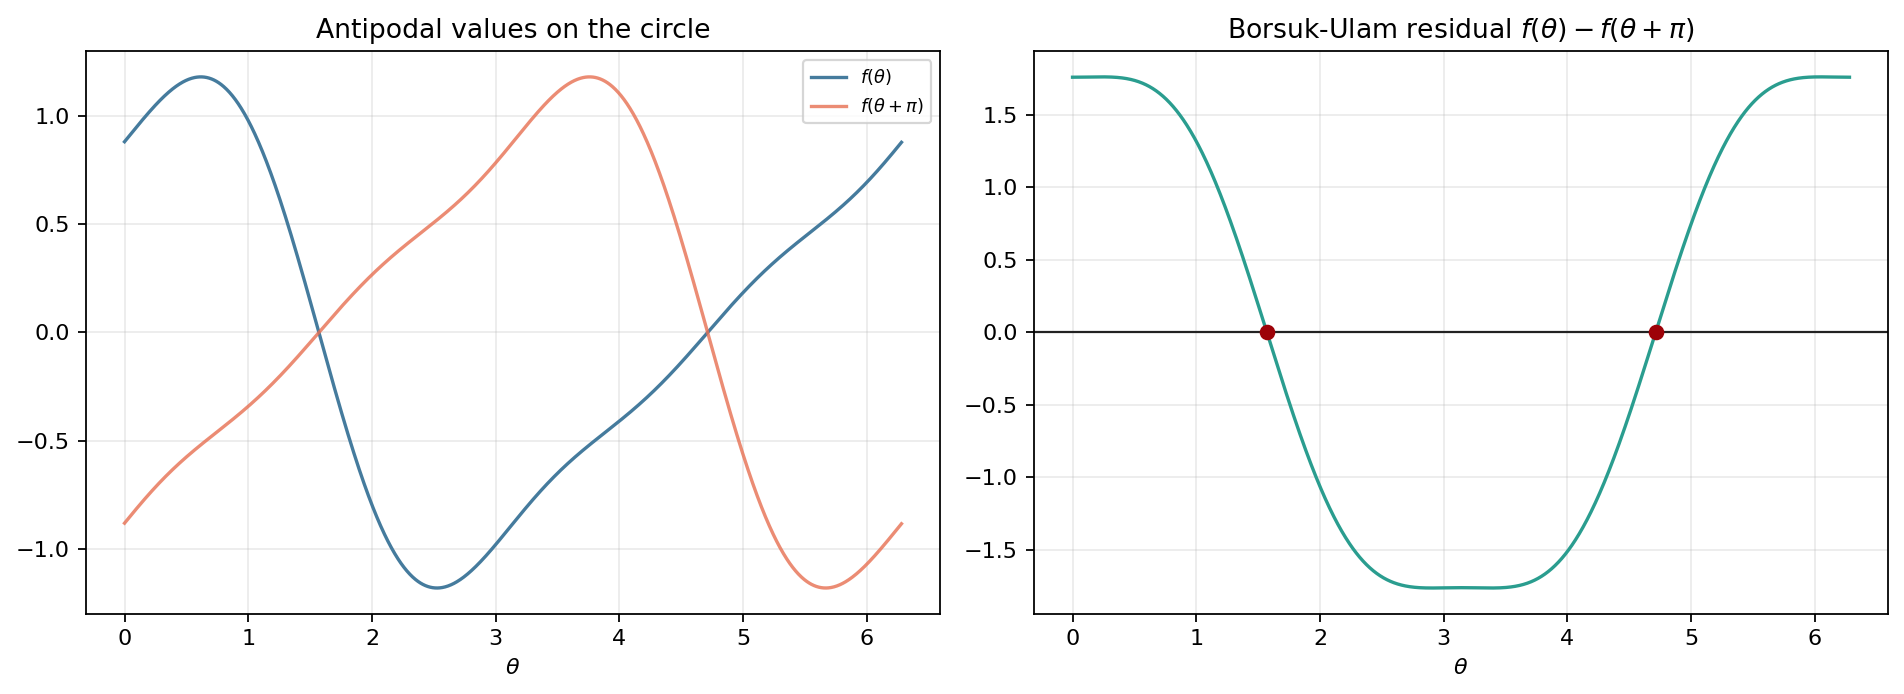

[{'theta': 1.570796,
  'antipode': 4.712389,
  'f_theta': 0.0,
  'f_antipode': -0.0,
  'residual_abs': 2.4737865342776534e-16},
 {'theta': 4.712389,
  'antipode': 1.570796,
  'f_theta': -0.0,
  'f_antipode': 0.0,
  'residual_abs': 9.65095955404505e-16}]

In [5]:
def f_circle(th):
    return np.cos(th) + 0.35*np.sin(2*th) - 0.12*np.cos(3*th)

def residual(th):
    return f_circle(th) - f_circle(th + np.pi)

th = np.linspace(0, 2*np.pi, 1600, endpoint=False)
r = residual(th)
roots = []
for i in range(len(th)):
    j = (i + 1) % len(th)
    if r[i] == 0:
        roots.append(float(th[i]))
    elif r[i] * r[j] < 0:
        a = float(th[i])
        b = float(th[j] if j > i else 2*np.pi)
        fa = float(residual(a))
        fb = float(residual(b))
        for _ in range(50):
            mid = 0.5 * (a + b)
            fm = float(residual(mid))
            if fa * fm <= 0:
                b, fb = mid, fm
            else:
                a, fa = mid, fm
        roots.append(float((0.5 * (a + b)) % (2*np.pi)))
root_rows = []
for root in roots:
    root_rows.append({
        "theta": round(root, 6),
        "antipode": round((root + np.pi) % (2*np.pi), 6),
        "f_theta": round(float(f_circle(root)), 6),
        "f_antipode": round(float(f_circle(root + np.pi)), 6),
        "residual_abs": abs(float(residual(root))),
    })

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(th, f_circle(th), color="#457b9d", label=r"$f(\theta)$")
axes[0].plot(th, f_circle(th + np.pi), color="#e76f51", label=r"$f(\theta+\pi)$", alpha=0.8)
axes[0].set_title("Antipodal values on the circle")
axes[0].set_xlabel(r"$\theta$")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)
axes[1].axhline(0, color="#222222", lw=1)
axes[1].plot(th, r, color="#2a9d8f")
axes[1].scatter([row["theta"] for row in root_rows], [0]*len(root_rows), color="#9d0208", zorder=3)
axes[1].set_title(r"Borsuk-Ulam residual $f(\theta)-f(\theta+\pi)$")
axes[1].set_xlabel(r"$\theta$")
axes[1].grid(alpha=0.25)
fig.tight_layout()
bu_path = save_matplotlib(fig, FIGURES / "borsuk-ulam-antipodal-residual-circle.png")
plt.close(fig)
bu_json = save_json({"roots": root_rows, "root_count": len(root_rows), "max_root_residual": max(row["residual_abs"] for row in root_rows)}, CHECKS / "borsuk-ulam-antipodal-residual-circle.json")
TRACKED_ARTIFACTS.extend([bu_path, bu_json])
display_artifact(bu_path, width=840)
root_rows[:6]


## Applied Lab: What To Count And Why It Survives

The practical workflow for this chapter is short but powerful. First, make the relevant map transverse, or identify where transversality fails. Second, verify compactness or boundary conditions so the intersection set is finite or the swept-out set is a compact one-manifold. Third, count the finite set modulo two. Fourth, explain why a homotopy changes the count only by the boundary of a compact one-manifold, hence by an even number. This workflow appears in intersection theory, winding-number consequences, nonretraction statements, and antipodal coincidence arguments.

The visuals above correspond to each step. The line-circle family shows a nontransverse tangency where a pair of intersections is created or destroyed. The winding lab turns a closed curve into component labels in the complement. The antipodal residual plot makes the symmetry behind Borsuk-Ulam visible: the residual is forced to have zeros because it reverses sign under the antipodal shift. The saved JSON and CSV files are intentionally simple, because the invariant is simple: finite counts, parity, integer winding, and residual zeros.


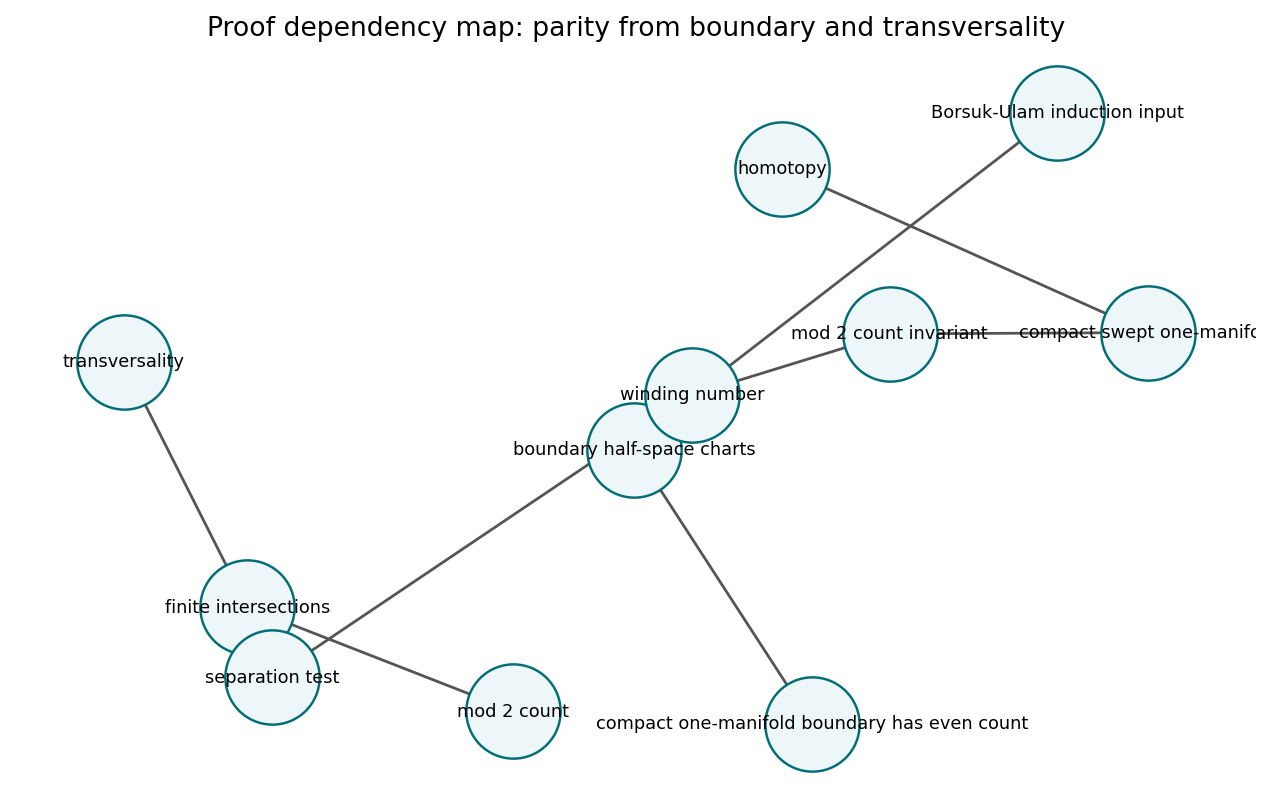

{'nodes': 11, 'edges': 8, 'acyclic': True}

In [6]:
# Dependency graph for the chapter's parity arguments.
G = nx.DiGraph()
edges = [
    ("boundary half-space charts", "compact one-manifold boundary has even count"),
    ("transversality", "finite intersections"),
    ("finite intersections", "mod 2 count"),
    ("homotopy", "compact swept one-manifold"),
    ("compact swept one-manifold", "mod 2 count invariant"),
    ("mod 2 count invariant", "winding number"),
    ("winding number", "separation test"),
    ("winding number", "Borsuk-Ulam induction input"),
]
G.add_edges_from(edges)
pos = nx.spring_layout(G, seed=23, k=0.85)
fig, ax = plt.subplots(figsize=(10, 6))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", edge_color="#555555", width=1.25)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#edf6f9", edgecolors="#006d77", linewidths=1.1, node_size=1800)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
ax.set_title("Proof dependency map: parity from boundary and transversality")
ax.axis("off")
dep_path = save_matplotlib(fig, FIGURES / "parity-winding-borsuk-ulam-dependencies.png")
plt.close(fig)
dep_json = save_json({"nodes": list(G.nodes), "edges": edges, "acyclic": nx.is_directed_acyclic_graph(G)}, CHECKS / "parity-winding-borsuk-ulam-dependencies.json")
TRACKED_ARTIFACTS.extend([dep_path, dep_json])
display_artifact(dep_path, width=780)
{"nodes": G.number_of_nodes(), "edges": G.number_of_edges(), "acyclic": nx.is_directed_acyclic_graph(G)}


In [7]:
assert sum(row["boundary_points"] for row in component_rows) % 2 == 0
assert any(not row["transverse"] for row in intersection_rows)
assert all(row["mod2_count"] == 0 for row in intersection_rows if row["transverse"])
assert max(abs(row["winding_raw"] - row["winding_integer"]) for row in winding_rows) < 1e-3
assert len(root_rows) >= 2
assert max(row["residual_abs"] for row in root_rows) < 5e-3
assert_artifacts(TRACKED_ARTIFACTS, min_bytes=80)
final_sanity = {
    "unit": UNIT_KEY,
    "tracked_artifacts": len(TRACKED_ARTIFACTS),
    "core_checks": ["compact one-manifold boundary even", "transverse parity stable", "winding is integer", "antipodal residual has zeros"],
}
final_sanity


{'unit': 'chapter-02-transversality-and-intersection',
 'tracked_artifacts': 13,
 'core_checks': ['compact one-manifold boundary even',
  'transverse parity stable',
  'winding is integer',
  'antipodal residual has zeros']}

## Takeaways

A boundary is not an afterthought; it is the mechanism that makes parity arguments work. Compact one-manifolds have boundary points in pairs, so a homotopy that sweeps intersections through a one-dimensional space preserves mod two counts. Transversality is the hypothesis that makes intersection sets finite and stable enough to count. Winding numbers package mod two and integer intersection information into a function on the complement of a closed curve. Borsuk-Ulam uses the same kind of topological pressure in a symmetric setting: antipodal points cannot always be separated by a smooth scalar measurement.

For later chapters, remember the sequence: perturb to transverse position, count the finite set, use a compact one-manifold to compare counts, and then interpret the count as a topological invariant.
